In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# 1. Uninstall the current PyTorch version
!pip uninstall -y torch torchvision torchaudio

# 2. Install the correct PyTorch version compatible with P100 GPU
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# 3. Install other required libraries (corrected 'accelerators' to 'accelerate')
!pip install -q diffusers transformers accelerate xformers pandas tqdm open-clip-torch

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 81.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 45.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 107.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# Install required core libraries
!pip install -q diffusers transformers accelerate xformers pandas tqdm open-clip-torch

# Install official AI tools for face restoration and enhancement
!pip install -q gfpgan facexlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 12.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/52.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 15.9 MB/s eta 0:00:00


In [4]:
# Paste this trick at the very top (BasicsR / GFPGAN Bug Fix) 
import sys
import torchvision.transforms.functional as Functional
sys.modules['torchvision.transforms.functional_tensor'] = Functional


import torch
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
import os
import pandas as pd
from tqdm import tqdm
import random
import cv2
import numpy as np
from PIL import Image
from gfpgan import GFPGANer

#CONFIGURATION 
MODEL_ID = "runwayml/stable-diffusion-v1-5" 
OUTPUT_DIR = "./kaggle_festival_dataset"
IMAGES_PER_CATEGORY = 5  # Increase to 50 or 100 after testing

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CATEGORIES = {
    "eid": [
        "A realistic DSLR photo of a Bangladeshi Muslim boy in a white traditional panjabi hugging his father, Eid Mubarak, emotional family moment, highly detailed face, 8k resolution, shot on 85mm lens, sharp focus",
        "A South Asian Muslim family sharing traditional sweets during Eid al-Fitr, authentic Dhaka house interior, warm morning sunlight, candid photography, cinematic lighting, photorealistic",
        "Traditional Eid-ul-Fitr prayer congregation at a historic Bangladeshi mosque, sunny day, thousands of devotees, wide angle cinematic shot, professional National Geographic style"
    ],
    "puja": [
        "A photorealistic shot of magnificent Goddess Durga idol inside a traditional pandal, intricate clay jewelry details, dhunuchi dance smoke atmosphere, dramatic festive lighting, ultra-realistic 8k, award-winning photography",
        "Bengali Hindu women in traditional red-and-white sarees celebrating Durga Puja, playing sindoor khela, joyful expressions, detailed face, photorealistic, cinematic sharp focus",
        "A close up DSLR shot of Goddess Durga idol face, focus on the third eye, cinematic lighting, cultural festival of Bangladesh, masterpiece, high-end commercial photography"
    ],
    "christmas": [
        "A beautifully decorated Christmas tree inside a cozy home in Dhaka, glowing fairy lights, gifts underneath, warm festive indoor atmosphere, 35mm lens look, hyper-detailed, photorealistic",
        "A South Asian family celebrating Christmas dinner together, laughing, wearing winter clothes, soft candle lighting, real-life documentary photography style, high resolution, detailed skin",
        "Cinematic macro shot of colorful Christmas ornaments and golden fairy lights, soft blurred bokeh background, holiday spirit, premium aesthetic wallpaper quality, photorealistic"
    ]
}

NEGATIVE_PROMPT = (
    "blurry, deformed eyes, deformed pupils, bad anatomy, distorted face, extra limbs, "
    "low quality, low resolution, watermark, text, signature, cartoon, anime, 3d render, "
    "cgi, painting, drawing, illustration, mutated hands, extra fingers, plastic skin, "
    "cloned face, double face, disproportionate body, oversaturated"
)







def setup_pipeline():
    print(f"Loading Text-to-Image Model: {MODEL_ID}...")
    try:
        pipe = StableDiffusionPipeline.from_pretrained(
            MODEL_ID, torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32
        )
        pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
        pipe = pipe.to(DEVICE)
        if DEVICE == "cuda":
            pipe.enable_attention_slicing()
        print("Text-to-Image Model loaded successfully!")
        return pipe
    except Exception as e:
        print(f"Error loading model: {e}")
        return None

def setup_face_fixer():
    print("Loading GFPGAN Face Restoration Model...")
    try:
        face_enhancer = GFPGANer(
            model_path='https://github.com/TencentARC/GFPGAN/releases/download/v1.3.0/GFPGANv1.4.pth',
            upscale=1, 
            arch='clean',
            channel_multiplier=2,
            device=torch.device(DEVICE)
        )
        print("Face Restoration Model loaded successfully!")
        return face_enhancer
    except Exception as e:
        print(f"Face fixer loading failed, using default output: {e}")
        return None

def fix_face(image_pil, face_enhancer):
    if face_enhancer is None:
        return image_pil
    
    open_cv_image = np.array(image_pil) 
    open_cv_image = open_cv_image[:, :, ::-1].copy() 
    
    _, _, restored_img = face_enhancer.enhance(open_cv_image, has_aligned=False, only_center_face=False, paste_back=True)
    
    restored_img = cv2.cvtColor(restored_img, cv2.COLOR_BGR2RGB)
    return Image.fromarray(restored_img)

def generate_dataset():
    pipe = setup_pipeline()
    face_enhancer = setup_face_fixer()
    
    if pipe is None: return

    metadata = []
    images_base_dir = os.path.join(OUTPUT_DIR, "images")
    
    for cat in CATEGORIES.keys():
        os.makedirs(os.path.join(images_base_dir, cat), exist_ok=True)

    total_images = len(CATEGORIES) * IMAGES_PER_CATEGORY
    print(f"\nStarting Dataset Generation (Total Images: {total_images})...")
    
    progress_bar = tqdm(total=total_images, desc="Overall Progress")
    
    for cat, prompts in CATEGORIES.items():
        print(f"\nGenerating Category: {cat.upper()}")
        for i in range(IMAGES_PER_CATEGORY):
            base_prompt = random.choice(prompts)
            lighting = random.choice(["golden hour photography", "cinematic soft light", "authentic daylight"])
            final_prompt = f"{base_prompt}, {lighting}, highly detailed skin texture, 4k, hyper-realistic"
            
            image_name = f"{cat}_{i+1:04d}.jpg"
            image_path = os.path.join(images_base_dir, cat, image_name)
            
            try:
                with torch.inference_mode():
                    output = pipe(
                        prompt=final_prompt,
                        negative_prompt=NEGATIVE_PROMPT,
                        num_inference_steps=35,   
                        guidance_scale=8.0,       
                        width=512,               
                        height=512
                    )
                    raw_image = output.images[0]
                
                final_image = fix_face(raw_image, face_enhancer)
                final_image.save(image_path, quality=95)
                
                metadata.append({
                    "file_id": f"{cat}_{i+1:04d}",
                    "file_path": f"images/{cat}/{image_name}",
                    "category": cat,
                    "prompt": final_prompt,
                    "lighting": lighting
                })
                
            except Exception as e:
                print(f"   Error generating {image_name}: {e}")
            
            progress_bar.update(1)

    progress_bar.close()

    df = pd.DataFrame(metadata)
    df.to_csv(os.path.join(OUTPUT_DIR, "metadata.csv"), index=False)
    
    print(f"\nDataset Generation Complete! Saved in: {OUTPUT_DIR}")

if __name__ == "__main__":
    generate_dataset()

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading Text-to-Image Model: runwayml/stable-diffusion-v1-5...


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

...

  0%|          | 0/35 [00:00<?, ?it/s]


Overall Progress:  93%|█████████▎| 14/15 [01:44<00:07,  7.66s/it]

  0%|          | 0/35 [00:00<?, ?it/s]


Overall Progress: 100%|██████████| 15/15 [01:52<00:00,  7.47s/it]


Dataset Generation Complete! Saved in: ./kaggle_festival_dataset


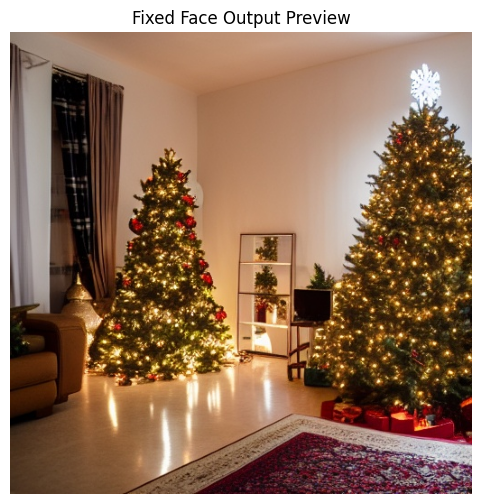

In [5]:
from PIL import Image
import matplotlib.pyplot as plt
import os

# Check the path of the first generated image
sample_path = "./kaggle_festival_dataset/images/christmas/christmas_0004.jpg"

if os.path.exists(sample_path):
    img = Image.open(sample_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Fixed Face Output Preview")
    plt.show()
else:
    print("Folder or image generation is not complete yet, or the file path is incorrect.")

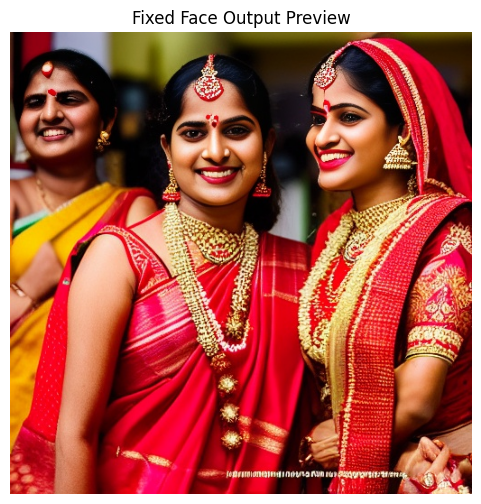

In [6]:
from PIL import Image
import matplotlib.pyplot as plt
import os

# Check the path of the first generated image
sample_path = "./kaggle_festival_dataset/images/puja/puja_0004.jpg"

if os.path.exists(sample_path):
    img = Image.open(sample_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Fixed Face Output Preview")
    plt.show()
else:
    print("Folder or image generation is not complete yet, or the file path is incorrect.")

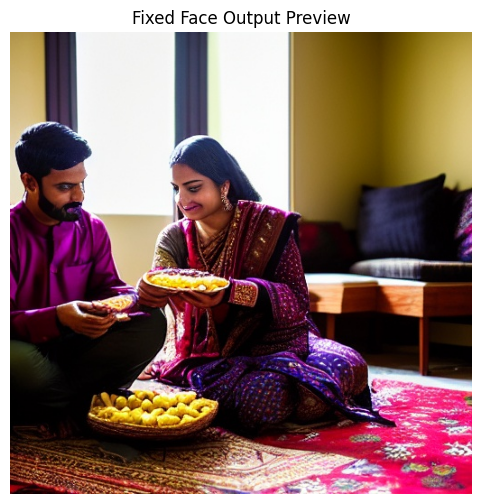

In [7]:
from PIL import Image
import matplotlib.pyplot as plt
import os

# Check the path of the first generated image
sample_path = "./kaggle_festival_dataset/images/eid/eid_0003.jpg"

if os.path.exists(sample_path):
    img = Image.open(sample_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Fixed Face Output Preview")
    plt.show()
else:
    print("Folder or image generation is not complete yet, or the file path is incorrect.")